# 08 – Evaluation: Importancia de Variables

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Analizar e interpretar cuáles variables tienen mayor impacto en las predicciones del modelo final, usando importancias de Random Forest y SHAP (opcional).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

SEL_DIR = os.path.join('..', 'data', 'selected')
SPLIT_DIR = os.path.join('..', 'data', 'split')
MODEL_DIR = os.path.join('..', 'models')
TARGET = 'target_desocupado'

try:
    df_train = pd.read_csv(os.path.join(SEL_DIR, 'epen_selected.csv'))
    X_test = pd.read_csv(os.path.join(SPLIT_DIR, 'X_test.csv'))
    y_test = pd.read_csv(os.path.join(SPLIT_DIR, 'y_test.csv')).squeeze()
    selected = pd.read_csv(os.path.join(SEL_DIR, 'selected_features.csv'))['selected_feature'].tolist()
    X_train = df_train[[c for c in selected if c in df_train.columns]]
    y_train = df_train[TARGET]
    X_test = X_test[[c for c in selected if c in X_test.columns]].fillna(0)
except FileNotFoundError:
    np.random.seed(42)
    n_train, n_test, n_feat = 800, 200, 8
    cols = [f'f{i}' for i in range(n_feat)]
    X_train = pd.DataFrame(np.random.randn(n_train, n_feat), columns=cols)
    y_train = pd.Series(np.random.choice([0, 1], n_train, p=[0.50, 0.50]))
    X_test = pd.DataFrame(np.random.randn(n_test, n_feat), columns=cols)
    y_test = pd.Series(np.random.choice([0, 1], n_test, p=[0.50, 0.50]))

rf_path = os.path.join(MODEL_DIR, 'random_forest.pkl')
if os.path.exists(rf_path):
    model = joblib.load(rf_path)
else:
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

print('Modelo listo.')

Modelo listo.


## 1. Importancia por Impureza Media (MDI – Mean Decrease Impurity)

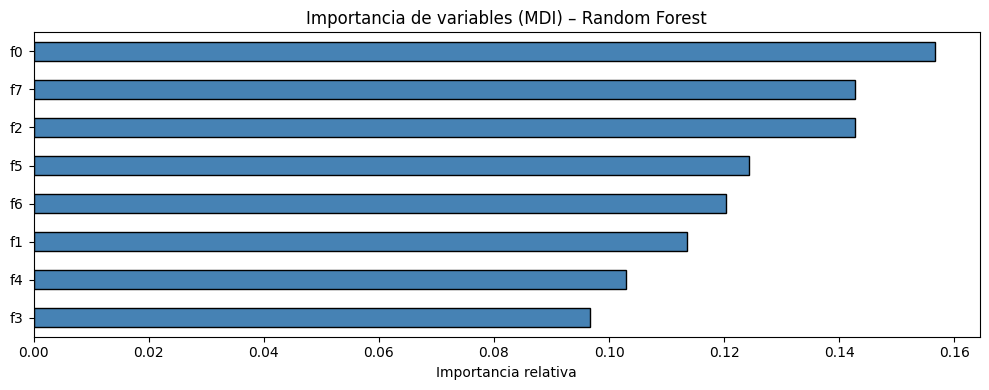

,MDI_Importance
f0,0.156628
f7,0.142801
f2,0.142719
f5,0.124292
f6,0.120400
f1,0.113520
f4,0.103022
f3,0.096618


In [2]:
feature_names = X_train.columns.tolist()
importances_mdi = pd.Series(model.feature_importances_, index=feature_names)\
    .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(feature_names) * 0.35)))
importances_mdi.plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Importancia de variables (MDI) – Random Forest')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

importances_mdi.sort_values(ascending=False).to_frame('MDI_Importance')

## 2. Importancia por Permutación (Permutation Importance)

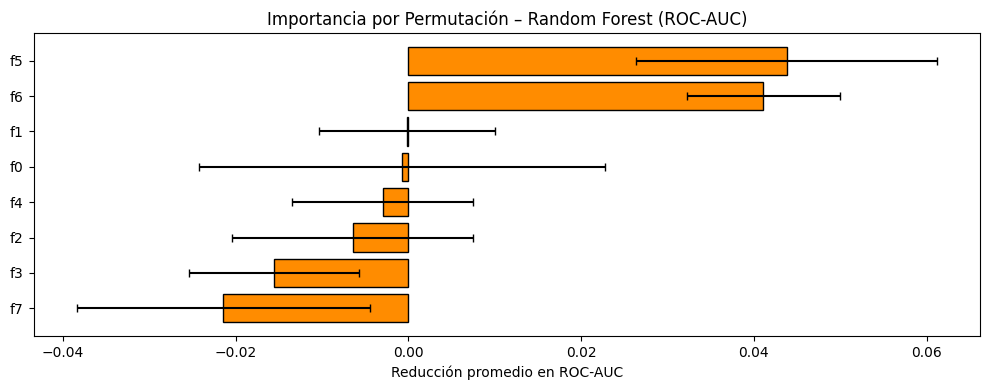

In [3]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

perm_imp = pd.DataFrame({
    'Variable': feature_names,
    'Mean': perm_result.importances_mean,
    'Std': perm_result.importances_std,
}).sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(feature_names) * 0.35)))
ax.barh(perm_imp['Variable'], perm_imp['Mean'],
        xerr=perm_imp['Std'], color='darkorange', edgecolor='black', capsize=3)
ax.set_title('Importancia por Permutación – Random Forest (ROC-AUC)')
ax.set_xlabel('Reducción promedio en ROC-AUC')
plt.tight_layout()
plt.show()

## 3. SHAP Values (opcional – requiere `pip install shap`)

C:\Users\guill\AppData\Local\Temp\ipykernel_15164\4185683423.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_class1, X_test, plot_type='bar', show=False)
C:\Users\guill\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\guill\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this 

<Figure size 1000x600 with 0 Axes>

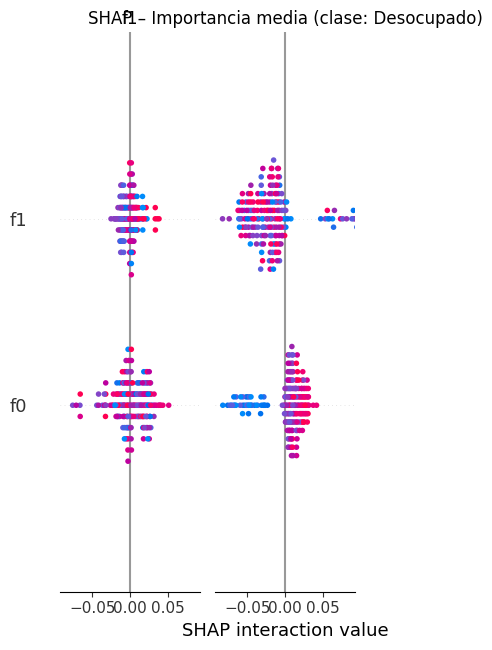

In [6]:
try:
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_class1, X_test, plot_type='bar', show=False)
    plt.title('SHAP – Importancia media (clase: Desocupado)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('SHAP no está instalado. Ejecuta: pip install shap')
    print('Los métodos MDI y Permutación son suficientes como alternativa.')

In [7]:
# Guardar tabla de importancias
RESULTS_DIR = os.path.join('..', 'data', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
importances_mdi.sort_values(ascending=False).to_frame('MDI_Importance').to_csv(
    os.path.join(RESULTS_DIR, 'feature_importance_final.csv')
)
print('Tabla guardada: data/results/feature_importance_final.csv')

Tabla guardada: data/results/feature_importance_final.csv
